In [1]:
# STEP 1: Install Required Libraries
# pip install nltk matplotlib wordcloud

In [2]:
# STEP 2: Import Required Libraries
import nltk
import re
import string
from collections import defaultdict
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [3]:
# Download required resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\VAIBHAV
[nltk_data]     ADMANE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\VAIBHAV
[nltk_data]     ADMANE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
# STEP 3: LOAD DOCUMENT FILES
# ⚠️ Make sure you have three text files in the specified path:
# doc1.txt, doc2.txt, doc3.txt
documents = {}
file_names = [r"C:\Users\VAIBHAV ADMANE\Downloads\doc1.txt",r"C:\Users\VAIBHAV ADMANE\Downloads\doc2.txt", r"C:\Users\VAIBHAV ADMANE\Downloads\doc3.txt"]

for file in file_names:
    with open(file, "r", encoding="utf-8") as f:
        documents[file] = f.read()

In [13]:
print("==============================================")
print("📄 ORIGINAL DOCUMENTS")
print("==============================================")
for name, content in documents.items():
    print(f"\n{name}:\n{content[:250]}...")  # print only first 250 chars


📄 ORIGINAL DOCUMENTS

C:\Users\VAIBHAV ADMANE\Downloads\doc1.txt:
Information retrieval is the process of obtaining relevant information from large collections of data.
It plays a vital role in modern technology such as search engines, digital libraries, and online databases.
Users provide queries to find the infor...

C:\Users\VAIBHAV ADMANE\Downloads\doc2.txt:
An inverted index is a key data structure in information retrieval systems.
It maps each term to the list of documents where that term appears.
This allows fast searching and efficient query processing.
Building an inverted index involves tokenizing ...

C:\Users\VAIBHAV ADMANE\Downloads\doc3.txt:
Search engines rely on information retrieval techniques to provide relevant results to users.
They use inverted indexes to map query terms to corresponding documents.
The preprocessing steps include tokenization, stopword removal, and stemming.
Natur...


In [14]:
# STEP 4: PREPROCESSING FUNCTION
def preprocess(text):
    """
    Performs text cleaning and tokenization:
    1. Converts to lowercase
    2. Removes punctuation
    3. Tokenizes
    4. Removes stopwords
    """
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = nltk.word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

In [15]:
# STEP 5: CREATE INVERTED INDEX
inverted_index = defaultdict(set)

# For each document, tokenize and store word-to-document mapping
for doc_name, content in documents.items():
    tokens = preprocess(content)
    for token in tokens:
        inverted_index[token].add(doc_name)

# Convert sets to sorted lists for clean output
for word in inverted_index:
    inverted_index[word] = sorted(list(inverted_index[word]))

print("\n==============================================")
print("📚 INVERTED INDEX (First 20 terms)")
print("==============================================")
for word, doc_list in list(inverted_index.items())[:20]:
    print(f"{word}: {doc_list}")


📚 INVERTED INDEX (First 20 terms)
information: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc2.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc3.txt']
retrieval: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc2.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc3.txt']
process: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt']
obtaining: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt']
relevant: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc2.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc3.txt']
large: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt']
collections: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt']
data: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc2.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc3.txt']
plays: ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt']
vital: ['C:\\Users\

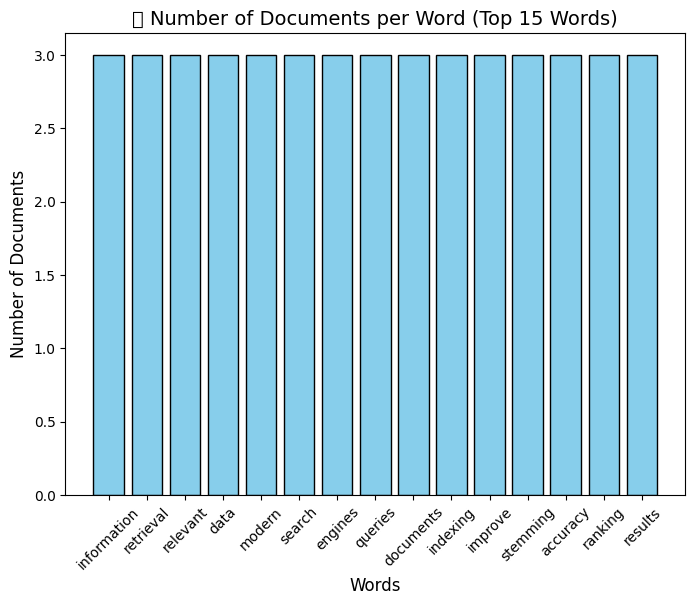

In [16]:
# STEP 6: VISUALIZATION - NUMBER OF DOCUMENTS PER WORD
word_counts = {word: len(doc_list) for word, doc_list in inverted_index.items()}
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
words = [item[0] for item in sorted_words[:15]]
counts = [item[1] for item in sorted_words[:15]]

plt.figure(figsize=(8,6))
plt.bar(words, counts, color='skyblue', edgecolor='black')
plt.title("📊 Number of Documents per Word (Top 15 Words)", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Number of Documents", fontsize=12)
plt.xticks(rotation=45)
plt.show()

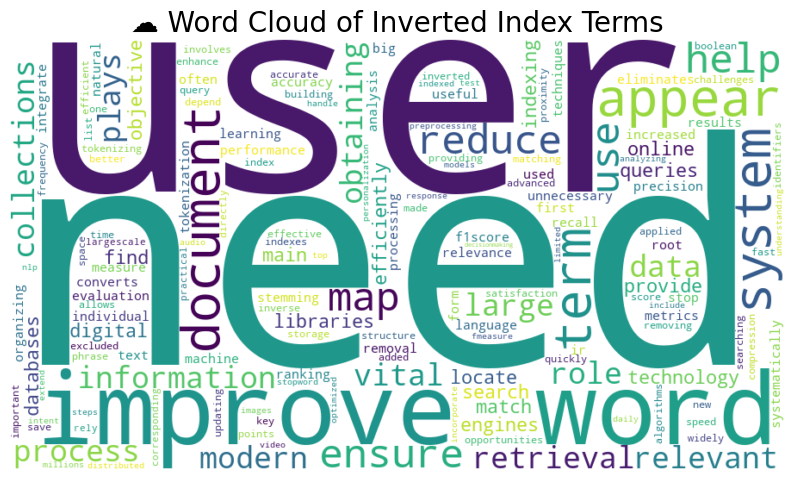

In [17]:
# STEP 7: VISUALIZATION - WORD CLOUD OF INDEX TERMS
final_terms = " ".join(inverted_index.keys())
wordcloud = WordCloud(width=900, height=500, background_color='white').generate(final_terms)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("☁️ Word Cloud of Inverted Index Terms", fontsize=20)
plt.show()

In [18]:
# STEP 8: DOCUMENT RETRIEVAL FUNCTION
def search(query):
    """
    Searches for documents that contain all query tokens.
    Implements Boolean AND retrieval model.
    """
    query_tokens = preprocess(query)
    if not query_tokens:
        print("❌ No valid search terms found.")
        return

    print("\n🔍 SEARCH QUERY TOKENS:", query_tokens)
    result_docs = None

    for token in query_tokens:
        docs_for_word = set(inverted_index.get(token, []))
        if result_docs is None:
            result_docs = docs_for_word
        else:
            result_docs = result_docs.intersection(docs_for_word)

    if result_docs:
        print(f"✅ Documents matching '{query}': {sorted(list(result_docs))}")
    else:
        print(f"⚠️ No documents found for query: '{query}'")

In [19]:
# STEP 9: TEST THE SEARCH FUNCTION
print("\n==============================================")
print("🔎 SAMPLE SEARCH TESTS")
print("==============================================")

search("information retrieval")
search("inverted index")
search("tokenization")
search("query processing")
search("boolean search")


🔎 SAMPLE SEARCH TESTS

🔍 SEARCH QUERY TOKENS: ['information', 'retrieval']
✅ Documents matching 'information retrieval': ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc2.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc3.txt']

🔍 SEARCH QUERY TOKENS: ['inverted', 'index']
✅ Documents matching 'inverted index': ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc2.txt']

🔍 SEARCH QUERY TOKENS: ['tokenization']
✅ Documents matching 'tokenization': ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc1.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc3.txt']

🔍 SEARCH QUERY TOKENS: ['query', 'processing']
✅ Documents matching 'query processing': ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc2.txt', 'C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc3.txt']

🔍 SEARCH QUERY TOKENS: ['boolean', 'search']
✅ Documents matching 'boolean search': ['C:\\Users\\VAIBHAV ADMANE\\Downloads\\doc2.txt']
